In [1]:
import numpy as np, pandas as pd, cv2
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 1.26.4
Pandas: 2.2.2
OpenCV: 4.12.0


In [1]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler

# ======================================
# 1. Load dataset with 3-row header
# ======================================
path = r"E:\ML_Project\all_participants_features_e4.csv"

header_rows = pd.read_csv(path, nrows=3, header=None)

cols = []
for i in range(header_rows.shape[1]):
    top = str(header_rows.iat[0, i]) if pd.notna(header_rows.iat[0, i]) else ""
    mid = str(header_rows.iat[1, i]) if pd.notna(header_rows.iat[1, i]) else ""
    bot = str(header_rows.iat[2, i]) if pd.notna(header_rows.iat[2, i]) else ""

    if i == 0 or bot.lower() == "datetime":
        cols.append("datetime")
    elif top and mid:
        cols.append(f"{top}_{mid}")
    elif top:
        cols.append(top)
    elif mid:
        cols.append(mid)
    else:
        cols.append(f"col_{i}")

df = pd.read_csv(path, skiprows=3, names=cols, low_memory=False)

# ======================================
# 2. Datetime + participant handling
# ======================================
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime'])

if 'participant' not in df.columns:
    raise ValueError("❌ 'participant' column not found in dataset!")

df = df.sort_values(by=['participant', 'datetime']).reset_index(drop=True)

print("✅ Data loaded and sorted by participant+datetime")
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

# ✅ ✅ REMOVED RESAMPLING (Step 3 deleted)

# ======================================
# 4. Signal processing
# ======================================
def butter_bandpass_filter(data, lowcut, highcut, fs=1, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = min(highcut / nyq, 0.99)
    if low >= high:
        raise ValueError("Invalid frequency band — skipping filter.")
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# BVP filtering (still checked, but dataset is assumed 1 Hz)
if 'bvp_mean' in df.columns:
    fs = 1
    if fs <= 2:
        print("ℹ️ Skipping BVP filtering — 1 Hz data insufficient for 0.5–0.9 Hz band.")
        df['bvp_filtered'] = df['bvp_mean']
    else:
        df['bvp_filtered'] = np.nan
        for pid, group in df.groupby('participant'):
            try:
                filtered = butter_bandpass_filter(group['bvp_mean'].fillna(0).values, 0.5, 0.9, fs=fs)
                df.loc[group.index, 'bvp_filtered'] = filtered
            except Exception as e:
                print(f"⚠️ Skipping BVP filter for {pid}: {e}")

# ✅ ACC magnitude (KEEP this)
if all(col in df.columns for col in ['x_mean', 'y_mean', 'z_mean']):
    df['acc_mag'] = np.sqrt(df['x_mean']**2 + df['y_mean']**2 + df['z_mean']**2)
    df['acc_mag_smooth'] = df.groupby('participant')['acc_mag'].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean()
    )
    print("✅ ACC magnitude computed")

    # ✅ DROP x, y, z columns
    df = df.drop(columns=['x_mean', 'y_mean', 'z_mean','x_std','y_std','z_std'], errors='ignore')
    print("✅ Dropped x_mean, y_mean, z_mean columns")

# ❌ REMOVE Temperature entirely
df = df.drop(columns=[col for col in df.columns if 'temp' in col.lower()], errors='ignore')
print("✅ Removed temperature-related columns")

# ======================================
# 5. Normalization (per participant)
# ======================================
normalized = []
for pid, group in df.groupby('participant'):
    num_cols = group.select_dtypes(include=[np.number]).columns
    num_cols = [c for c in num_cols if group[c].std(skipna=True) > 0]
    group[num_cols] = StandardScaler().fit_transform(group[num_cols])
    normalized.append(group)

df = pd.concat(normalized).reset_index(drop=True)

print("✅ Normalized per participant")
print("✅ Final shape:", df.shape)
print(df.head())


✅ Data loaded and sorted by participant+datetime
Columns: ['datetime', 'x_mean', 'x_std', 'y_mean', 'y_std', 'z_mean', 'z_std', 'bvp_mean', 'bvp_std', 'hr_mean', 'hr_std', 'ibi_mean', 'ibi_std', 'temp_mean', 'temp_std', 'participant']
Shape: (91595, 16)
ℹ️ Skipping BVP filtering — 1 Hz data insufficient for 0.5–0.9 Hz band.
✅ ACC magnitude computed
✅ Dropped x_mean, y_mean, z_mean columns
✅ Removed temperature-related columns
✅ Normalized per participant
✅ Final shape: (91595, 11)
             datetime   bvp_mean   bvp_std   hr_mean    hr_std  ibi_mean  \
0 2024-03-18 04:18:08  23.429903       NaN  0.829672       NaN  0.313582   
1 2024-03-18 04:18:09 -19.476397  2.910965  0.829672 -0.666652  0.313582   
2 2024-03-18 04:18:10   0.040524  2.462457  0.829672 -0.666652  0.313582   
3 2024-03-18 04:18:11   1.694919  1.729142  0.829672 -0.666652  0.313582   
4 2024-03-18 04:18:12  -7.332594  1.651609  0.829672 -0.666652  0.313582   

   ibi_std participant  bvp_filtered   acc_mag  acc_mag_s

In [3]:
# ======================================
# 6. Save Preprocessed Data
# ======================================
df.to_csv(r"E:\ML_Project\Preprocessed Dataset\processed_e4.csv", index=False)

print("✅ Preprocessing complete. Saved as proccessed_e4.csv")


✅ Preprocessing complete. Saved as proccessed_e4.csv


In [2]:
import pandas as pd
import numpy as np
import neurokit2 as nk
from tqdm import tqdm

# ======================================
# Step 1: HRV Feature Extraction Helper
# ======================================
def extract_hrv_features(ibi_series, sampling_rate=1000):
    """
    Compute selected HRV features (time + frequency) from IBI series.
    Keeps only key features for stress modeling:
    HRV_MeanNN, HRV_SDNN, HRV_RMSSD, HRV_pNN50, HRV_LF, HRV_HF, HRV_LFHF
    """
    ibi_series = ibi_series.dropna().values
    if len(ibi_series) < 5:  # not enough data to compute HRV
        return None

    try:
        # Convert IBIs (s) → synthetic R-peak indices (ms)
        peaks = nk.intervals_to_peaks(ibi_series * 1000)

        # Compute HRV features
        hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate, show=False)
        hrv_freq = nk.hrv_frequency(peaks, sampling_rate=sampling_rate, show=False)

        # Select only required columns
        selected_cols = [
            "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD",
            "HRV_pNN50", "HRV_LF", "HRV_HF", "HRV_LFHF"
        ]
        combined = pd.concat([hrv_time, hrv_freq], axis=1)
        combined = combined.loc[:, combined.columns.intersection(selected_cols)]

        return combined

    except Exception as e:
        print(f"⚠️ HRV computation failed: {e}")
        return None


# ======================================
# Step 2: Sliding Window (1-min, 50% overlap)
# ======================================
window_size = 60  # seconds
step_size = 30    # 50% overlap
participant_features = []

for pid, group in tqdm(df.groupby('participant'), desc="Extracting HRV"):
    group = group.sort_values('datetime').reset_index(drop=True)

    if 'ibi_mean' not in group.columns:
        print(f"⚠️ Skipping participant {pid} — no IBI column found.")
        continue

    for start in range(0, len(group) - window_size, step_size):
        window = group.iloc[start:start + window_size]
        hrv_features = extract_hrv_features(window['ibi_mean'])

        if hrv_features is not None:
            # Add metadata
            hrv_features['participant'] = pid
            hrv_features['window_start'] = window['datetime'].iloc[0]
            hrv_features['window_end'] = window['datetime'].iloc[-1]
            # Midpoint for merge_asof alignment later
            hrv_features['timestamp'] = window['datetime'].iloc[len(window)//2]
            participant_features.append(hrv_features)


# ======================================
# Step 3: Combine All Participants’ Features
# ======================================
hrv_df = pd.concat(participant_features, ignore_index=True)
print("✅ HRV feature extraction complete:", hrv_df.shape)

# ======================================
# Step 4: Save Results (Optional)
# ======================================
#hrv_df.to_csv(r"E:\ML_Project\e4_hrv_features_selected.csv", index=False)
#print("✅ Saved selected HRV features to e4_hrv_features_selected.csv")


Extracting HRV:   0%|                                                                           | 0/24 [00:00<?, ?it/s]C:\Users\Nathan and Neil\AppData\Roaming\Python\Python312\site-packages\neurokit2\signal\signal_interpolate.py:119: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(
C:\Users\Nathan and Neil\AppData\Roaming\Python\Python312\site-packages\neurokit2\signal\signal_interpolate.py:119: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(
C:\Users\Nathan and Neil\AppData\Roaming\Python\Python312\site-packages\neurokit2\signal\signal_interpolate.py:119: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(
C:\Users\Nathan and Neil\AppData\Roaming\Python\Python312\site-packages\neurokit2\signal\signal_interpolate.py:119: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(
C:\Users\Nathan and Neil\AppData\Roaming\

✅ HRV feature extraction complete: (3018, 11)


In [3]:
import numpy as np
import pandas as pd

hrv_df = pd.read_csv(r"E:\ML_Project\Preprocessed Dataset\e4_hrv_features_selected.csv")

# --- Handle missing values ---
# Replace missing LF/HF and SDNN values with group-wise medians (optional: overall median)
hrv_df['HRV_LFHF'] = hrv_df['HRV_LFHF'].fillna(hrv_df['HRV_LFHF'].median())
hrv_df['HRV_SDNN'] = hrv_df['HRV_SDNN'].fillna(hrv_df['HRV_SDNN'].median())

# --- Stress classification function ---
def classify_stress(row):
    lf_hf = row['HRV_LFHF']
    sdnn = row['HRV_SDNN']

    if lf_hf < 1.5 and sdnn > 50:
        return "Low"
    elif 1.5 <= lf_hf <= 3 and 30 <= sdnn <= 50:
        return "Medium"
    elif lf_hf > 3 and sdnn < 30:
        return "High"
    else:
        # Fallbacks for borderline or missing conditions
        if lf_hf > 3:
            return "High"
        elif lf_hf < 1.5:
            return "Low"
        else:
            return "Medium"

# --- Apply classification ---
hrv_df["stress_level"] = hrv_df.apply(classify_stress, axis=1)

# --- Verify results ---
print("✅ Stress level labeling complete (no NaNs).")
print(hrv_df["stress_level"].value_counts())

# Optional numeric mapping
# hrv_df["stress_label"] = hrv_df["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})

# --- Optional save ---
#hrv_df.to_csv(r"E:\ML_Project\Preprocessed Dataset\e4_hrv_features_labeled.csv", index=False)
#print("💾 Saved labeled HRV features with stress_level column.")


✅ Stress level labeling complete (no NaNs).
stress_level
High      2621
Low        246
Medium     151
Name: count, dtype: int64


In [4]:
import pandas as pd

# --- Step 1: Load both datasets ---
hrv_df = pd.read_csv(r"E:\ML_Project\Preprocessed Dataset\e4_hrv_features_labeled.csv")
pre_df = pd.read_csv(r"E:\ML_Project\Preprocessed Dataset\processed_e4.csv")

# --- Step 2: Rename to a common time column ---
# (We’ll use 'timestamp' for consistency)
if 'datetime' in pre_df.columns:
    pre_df.rename(columns={'datetime': 'timestamp'}, inplace=True)

# --- Step 3: Convert both to datetime ---
hrv_df['timestamp'] = pd.to_datetime(hrv_df['timestamp'])
pre_df['timestamp'] = pd.to_datetime(pre_df['timestamp'])

print("HRV dataframe shape:", hrv_df.shape)
print("E4 dataframe shape:", pre_df.shape)
print("Common columns for merging:", 'timestamp' in pre_df.columns and 'timestamp' in hrv_df.columns)

# --- Step 4: Merge based on nearest timestamp ---
merged_df = pd.merge_asof(
    pre_df.sort_values('timestamp'),
    hrv_df.sort_values('timestamp'),
    on='timestamp',
    direction='nearest',
    tolerance=pd.Timedelta('1s')  # increase to '5s' or '30s' if HRV computed per minute
)

# --- Step 5: Drop rows without stress label ---
merged_df = merged_df.dropna(subset=['stress_level']).reset_index(drop=True)

# --- Step 6: Save final merged dataset ---
#merged_df.to_csv(r"E:\ML_Project\Preprocessed Dataset\merged_e4_hrv_stress.csv", index=False)

print("✅ Merge complete! Final shape:", merged_df.shape)
print(merged_df['stress_level'].value_counts())


HRV dataframe shape: (3018, 12)
E4 dataframe shape: (91595, 11)
Common columns for merging: True
✅ Merge complete! Final shape: (9054, 22)
stress_level
High      7863
Low        738
Medium     453
Name: count, dtype: int64


In [9]:
hrv_df[['HRV_LF', 'HRV_HF', 'HRV_LFHF']].isna().mean() * 100

HRV_LF      52.650762
HRV_HF      16.799205
HRV_LFHF     0.000000
dtype: float64

In [5]:
# Interpolate missing HRV_LF and HRV_HF per participant
for col in ['HRV_LF', 'HRV_HF']:
    if col in hrv_df.columns:
        hrv_df[col] = hrv_df.groupby('participant')[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )

# Fill remaining NaNs with global median (fallback)
hrv_df['HRV_LF'] = hrv_df['HRV_LF'].fillna(hrv_df['HRV_LF'].median())
hrv_df['HRV_HF'] = hrv_df['HRV_HF'].fillna(hrv_df['HRV_HF'].median())

# Optional: Drop rows where all HRV metrics are missing
hrv_df = hrv_df.dropna(subset=['HRV_LFHF'], how='all')


In [6]:
hrv_df[['HRV_LF', 'HRV_HF', 'HRV_LFHF', 'HRV_SDNN']].isna().sum()


HRV_LF      0
HRV_HF      0
HRV_LFHF    0
HRV_SDNN    0
dtype: int64

In [7]:
hrv_df[['HRV_LF', 'HRV_HF', 'HRV_LFHF', 'HRV_SDNN']].describe()

,HRV_LF,HRV_HF,HRV_LFHF,HRV_SDNN
count,3.018000e+03,3.018000e+03,3018.000000,3018.000000
mean,2.383829e-03,7.660081e-03,29.762667,233.399642
std,7.621641e-03,2.288300e-02,93.439393,205.935478
min,1.008512e-07,2.079591e-10,0.001133,0.129099
25%,2.329750e-04,6.273165e-05,9.569381,100.942466
50%,5.448411e-04,7.547970e-04,9.569381,179.922646
75%,1.754182e-03,4.438748e-03,9.569381,299.835896
max,9.080525e-02,2.149451e-01,1808.142235,1925.090775


In [9]:
import numpy as np

# --- Step 1: Cap LF/HF ratio ---
hrv_df['HRV_LFHF'] = np.clip(hrv_df['HRV_LFHF'], 0.1, 10)

# --- Step 2: Clip SDNN ---
hrv_df['HRV_SDNN'] = np.clip(hrv_df['HRV_SDNN'], 20, 300)

# --- Step 3: Optional sanity check ---
print(hrv_df[['HRV_LFHF', 'HRV_SDNN']].describe())


          HRV_LFHF     HRV_SDNN
count  3018.000000  3018.000000
mean      8.171267   182.726737
std       3.034503    94.118067
min       0.100000    20.000000
25%       9.569381   100.942466
50%       9.569381   179.922646
75%       9.569381   299.835896
max      10.000000   300.000000


In [12]:
# --- Compute percentile thresholds ---
lfhf_low = hrv_df['HRV_LFHF'].quantile(0.33)
lfhf_high = hrv_df['HRV_LFHF'].quantile(0.66)
sdnn_low = hrv_df['HRV_SDNN'].quantile(0.33)
sdnn_high = hrv_df['HRV_SDNN'].quantile(0.66)

print(f"LF/HF thresholds: low={lfhf_low:.2f}, high={lfhf_high:.2f}")
print(f"SDNN thresholds: low={sdnn_low:.2f}, high={sdnn_high:.2f}")

def adaptive_label_stress(row):
    lf_hf = row['HRV_LFHF']
    sdnn = row['HRV_SDNN']
    
    if lf_hf < lfhf_low and sdnn > sdnn_high:
        return 'Low'
    elif lfhf_low <= lf_hf <= lfhf_high and sdnn_low <= sdnn <= sdnn_high:
        return 'Medium'
    elif lf_hf > lfhf_high and sdnn < sdnn_low:
        return 'High'
    else:
        return 'Medium'  # fallback for unclassified cases

hrv_df['stress_level'] = hrv_df.apply(adaptive_label_stress, axis=1)
print(hrv_df['stress_level'].value_counts())


LF/HF thresholds: low=9.57, high=9.57
SDNN thresholds: low=123.11, high=243.78
stress_level
Medium    2629
Low        268
High       121
Name: count, dtype: int64


In [13]:
lfhf_low = max(1.5, hrv_df['HRV_LFHF'].quantile(0.33))
lfhf_high = min(3.0, hrv_df['HRV_LFHF'].quantile(0.66))
sdnn_low = hrv_df['HRV_SDNN'].quantile(0.33)
sdnn_high = hrv_df['HRV_SDNN'].quantile(0.66)

print(f"Adjusted LF/HF thresholds: low={lfhf_low:.2f}, high={lfhf_high:.2f}")
print(f"SDNN thresholds: low={sdnn_low:.2f}, high={sdnn_high:.2f}")

def refined_label_stress(row):
    lf_hf = row['HRV_LFHF']
    sdnn = row['HRV_SDNN']
    
    if lf_hf < lfhf_low and sdnn > sdnn_high:
        return 'Low'
    elif lfhf_low <= lf_hf <= lfhf_high and sdnn_low <= sdnn <= sdnn_high:
        return 'Medium'
    elif lf_hf > lfhf_high and sdnn < sdnn_low:
        return 'High'
    else:
        return 'Medium'

hrv_df['stress_level'] = hrv_df.apply(refined_label_stress, axis=1)
print(hrv_df['stress_level'].value_counts())


Adjusted LF/HF thresholds: low=9.57, high=3.00
SDNN thresholds: low=123.11, high=243.78
stress_level
Medium    1900
High       850
Low        268
Name: count, dtype: int64


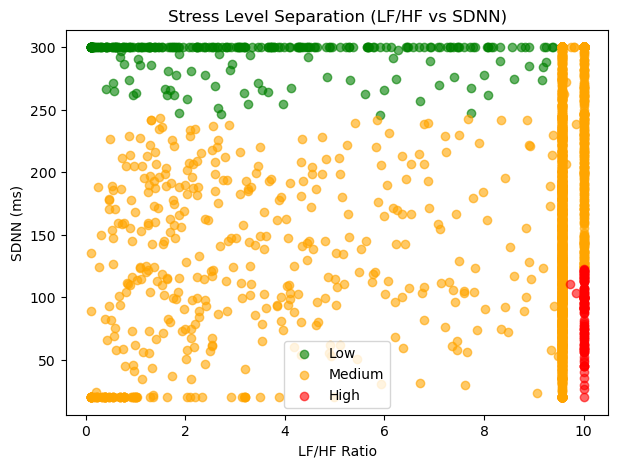

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
for label, color in zip(['Low', 'Medium', 'High'], ['green', 'orange', 'red']):
    subset = hrv_df[hrv_df['stress_level'] == label]
    plt.scatter(subset['HRV_LFHF'], subset['HRV_SDNN'], label=label, alpha=0.6, c=color)

plt.xlabel('LF/HF Ratio')
plt.ylabel('SDNN (ms)')
plt.title('Stress Level Separation (LF/HF vs SDNN)')
plt.legend()
plt.show()
